In [1]:
import matplotlib.pyplot as plt
import scipy as sc
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import seaborn as sns
import sys
import os
import torch
from tqdm import tqdm

In [2]:
dataset = 'shakespeare_char' # or whatever your data folder is named
data_dir = os.path.join('data', dataset)

In [3]:
sys.path.insert(0, os.getcwd())

from model import GPTConfig, GPT
from lib.utils import get_batch

In [4]:
device='cpu'
dataset='shakespeare_char'
checkpoint_dir='out-shakespeare-char'

In [5]:
%%capture
torch.manual_seed(1337)

# load the checkpointed model state from last train save
ckpt_path = os.path.join(checkpoint_dir, 'ckpt.pt')
checkpoint = torch.load(ckpt_path, map_location=device)
gptconf = GPTConfig(**checkpoint['model_args'])
model = GPT(gptconf)
state_dict = checkpoint['model']
unwanted_prefix = '_orig_mod.'
for k,v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
model.load_state_dict(state_dict)

model.eval() # disables dropout
model.to(device)
model.config

In [6]:
model.config

GPTConfig(block_size=128, vocab_size=65, n_layer=15, n_head=12, head_size=20, batch_size=16, n_embd=128, dropout=0.2, bias=False, mlp_width=512)

In [7]:
n = model.config.block_size
h = model.config.n_head
hs = model.config.head_size

In [8]:
X, Y = get_batch('eval', os.path.join('data', dataset), device, n, model.config.batch_size)
A,T,v = model.get_matricies(X,0)

T.shape
# X.shape

(128, 20)

In [9]:
A_tensor = torch.as_tensor(A)
T_tensor = torch.as_tensor(T)

U, S, Vh = torch.linalg.svd(T_tensor, full_matrices=True)
r = torch.sum(S > 1e-5).item()

U_null = U[:, r:]

A_proj_null = U_null @ U_null.T @ A_tensor
A_perp = A_tensor - A_proj_null
print(A_perp)

tensor([[ 9.9687e-01,  5.6236e-03,  3.8708e-03,  ..., -1.2393e-04,
         -8.2443e-05, -3.7398e-05],
        [ 4.8929e-01,  4.8501e-01,  1.0753e-02,  ...,  7.2178e-04,
          4.4521e-04,  1.8661e-04],
        [ 3.4300e-01,  3.1463e-01,  3.1004e-01,  ...,  4.7781e-04,
          3.6945e-04,  2.1476e-04],
        ...,
        [ 1.5386e-02,  2.0612e-02,  3.1214e-03,  ...,  2.1662e-03,
          1.4432e-03,  7.2774e-04],
        [ 1.2289e-02,  1.7980e-02,  1.5796e-03,  ...,  2.2178e-03,
          1.5000e-03,  7.6110e-04],
        [ 8.8995e-03,  1.3664e-02,  1.7412e-03,  ...,  2.3050e-03,
          1.5688e-03,  8.0154e-04]])


In [10]:
def compute_head_behaviors(attentions):
    all_features = []
    n_layers = len(attentions)
    n_heads = attentions[0].shape[1]
    n_tokens = attentions[0].shape[-1]

    for layer_attn in attentions:
        # Average across the batch: shape (heads, seq, seq)
        avg_attn = layer_attn.mean(0).cpu().numpy() 
        
        for h in range(n_heads):
            head = avg_attn[h]
            
            # Selector logic from notebook
            # 'left' (previous char): diagonal -1
            left_mass = np.trace(head, offset=-1) / n_tokens
            # 'self' (current char): diagonal 0
            self_mass = np.trace(head, offset=0) / n_tokens
            # 'first' (start of sequence): first column
            first_mass = head[:, 0].mean()
            
            all_features.append([left_mass, self_mass, first_mass])
            
    return np.array(all_features)

In [11]:
print(len(model(X)))

3


In [12]:
def get_data_points(stat_matrix):
    xs, ys, avgs = [], [], []
    n_l, n_h = stat_matrix.shape
    for l in range(n_l):
        layer_vals = stat_matrix[l]
        for h in range(n_h):
            xs.append(l + 1) # x-axis is Layer 1, 2...
            ys.append(layer_vals[h])
        avgs.append(layer_vals.mean())
    return np.array(xs), np.array(ys), np.array(avgs)

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. SETUP PARAMETERS ---
n_layers = model.config.n_layer
n_heads = model.config.n_head
# Define colors to match your plotting script
RED, BLUE, PURPLE = "#e74c3c", "#3498db", "#9b59b6"

# Define what characters count as punctuation for your dataset
# (Shakespeare typically uses these)
PUNCT_TOKENS = ['.', ',', '!', '?', ';', ':']
punct_ids = [model.transformer.wte.weight.shape[0]] # fallback 

# Convert punctuation to token IDs if possible
try:
    import tiktoken # or your specific tokenizer
    # If using character-level nanoGPT:
    # stoi = model.stoi (if you have the mapping)
    # punct_ids = [stoi[c] for c in PUNCT_TOKENS if c in stoi]
except:
    pass 

# --- 2. STORAGE ---
avg_attns = {k: np.zeros((n_layers, n_heads)) for k in ["first", "punct", "prev", "self", "next"]}
num_eval_batches = 10

# --- 3. DATA COLLECTION LOOP ---
model.eval()
with torch.no_grad():
    for _ in tqdm(range(num_eval_batches), desc="Evaluating Attention"):
        # Get a batch of data
        X, Y = get_batch('val', data_dir, device, block_size, batch_size)
        ds = X.size(1)
        
        for l in range(n_layers):
            for h in range(n_heads):
                # Extract A from your model
                # Note: ensure get_matricies returns (ds, ds) for A
                A, _, _ = model.get_matricies(X, head_idx=h)
                A = torch.as_tensor(A)
                
                # --- Metrics Calculation ---
                # 1. First Token
                avg_attns["first"][l, h] += A[:, 0].mean().item()
                
                # 2. Current Token (Self)
                avg_attns["self"][l, h] += torch.diagonal(A, 0).mean().item()
                
                # 3. Previous Token
                if ds > 1:
                    avg_attns["prev"][l, h] += torch.diagonal(A, -1).mean().item()
                    # 4. Next Token (This should be 0 in causal models)
                    avg_attns["next"][l, h] += torch.diagonal(A, 1).mean().item()
                
                # 5. Punctuation
                # Find mask where tokens in X are in PUNCT_TOKENS
                # This highlights heads that look at sentence breaks
                is_punct = torch.zeros((ds,), dtype=torch.bool, device=device)
                for pid in punct_ids:
                    is_punct |= (X[0] == pid)
                
                if is_punct.any():
                    # Average attention paid to any punctuation column
                    avg_attns["punct"][l, h] += A[:, is_punct].sum(dim=1).mean().item()

# Normalize by batch count
for key in avg_attns:
    avg_attns[key] /= num_eval_batches

Evaluating Attention:   0%|          | 0/10 [00:00<?, ?it/s]


NameError: name 'block_size' is not defined

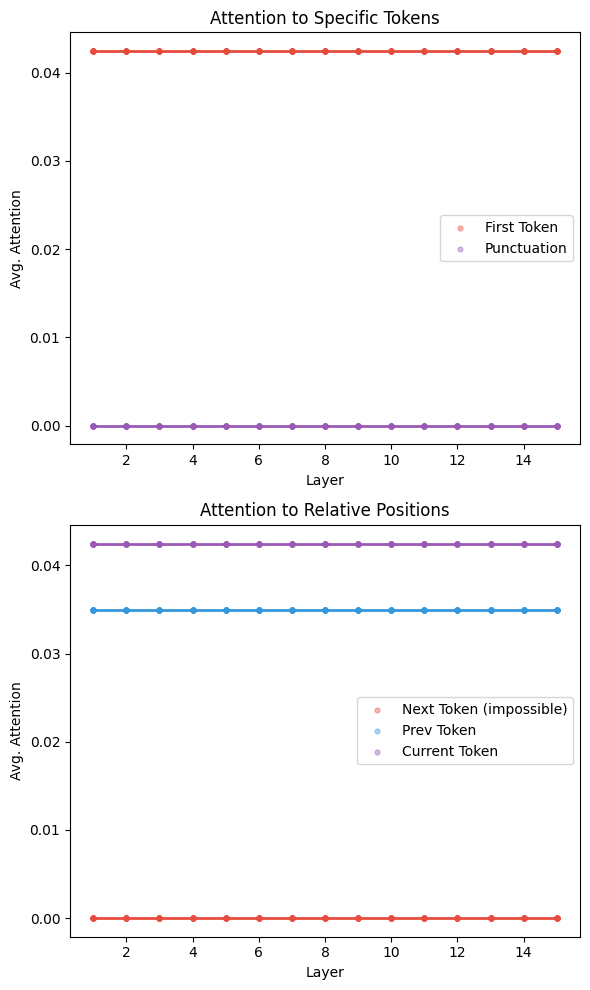

In [ ]:
def add_line(key, ax, color, label, plot_avgs=True):
    xs, ys, avgs = get_data_points(avg_attns[key])
    ax.scatter(xs, ys, s=12, label=label, color=color, alpha=0.4)
    if plot_avgs:
        ax.plot(1 + np.arange(len(avgs)), avgs, color=color, linewidth=2)
    ax.legend(loc="best")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Avg. Attention")

plt.figure(figsize=(6, 10))

# Subplot 1: Fixed Positions
ax1 = plt.subplot(2, 1, 1) # Changed to 2, 1 since we are skipping BERT [SEP]
for key, color, label in [
    ("first", RED, "First Token"),
    ("punct", PURPLE, "Punctuation"),
]:
    add_line(key, ax1, color, label)
ax1.set_title("Attention to Specific Tokens")

# Subplot 2: Relative Positions
ax3 = plt.subplot(2, 1, 2)
for key, color, label in [
    ("next", RED, "Next Token (impossible)"),
    ("prev", BLUE, "Prev Token"),
    ("self", PURPLE, "Current Token"),
]:
    add_line(key, ax3, color, label, plot_avgs=True)
ax3.set_title("Attention to Relative Positions")

plt.tight_layout()
plt.show()

In [14]:
import torch
import numpy as np

def get_effective_attention(A_tensor, T_tensor, eps=1e-5):
    """
    Computes effective attention A_perp as defined in Brunner et al. (2020).
    A_tensor: (seq_len, seq_len)
    T_tensor: (seq_len, head_dim)
    """
    # 1. SVD to find the null space basis of T
    U, S, Vh = torch.linalg.svd(T_tensor, full_matrices=True)
    
    # 2. Identify the rank r to find the left null space vectors
    r = torch.sum(S > eps).item()
    U_null = U[:, r:] # Left null space basis
    
    # 3. Project A onto the null space: A_proj = U_null @ U_null.T @ A
    # The paper defines A_perp = A - Projection_LN(T)(A)
    A_proj_null = U_null @ U_null.mT @ A_tensor
    A_perp = A_tensor - A_proj_null
    
    return A_perp

In [15]:
num_eval_batches = 10 # How many batches to average over
n_layers = model.config.n_layer
n_heads = model.config.n_head
block_size = model.config.block_size
batch_size = 16

# Initialize storage for stats
avg_attns_raw = {k: np.zeros((n_layers, n_heads)) for k in ["self", "first", "prev"]}
avg_attns_eff = {k: np.zeros((n_layers, n_heads)) for k in ["self", "first", "prev"]}

model.eval()
with torch.no_grad():
    for _ in tqdm(range(num_eval_batches)):
        # 1. Get a batch of Shakespeare data
        X, Y = get_batch('val', data_dir, device, block_size, batch_size)
        ds = X.size(1)
        
        # 2. Forward pass to get weights
        # (Assuming your modified model returns: logits, loss, attentions)
        logits, loss, attentions = model(X) 
        
        # 3. Process each layer
        for l in range(n_layers):
            # layer_attn shape: (batch, heads, seq, seq)
            layer_attn = attentions[l]
            
            # We need to compute T = X_in @ W_v @ W_proj for effective attention
            # For simplicity in this script, we take the average across the batch
            raw_A = layer_attn.mean(0) # (heads, seq, seq)
            
            for h in range(n_heads):
                A_raw_head = raw_A[h]
                
                # --- CALCULATE T FOR THIS HEAD ---
                # To be mathematically precise for A_perp, we need the Value mapping.
                # In NanoGPT, the value matrix V is essentially what A multiplies.
                # We can approximate the 'identifiability' check using the V matrix
                # from the forward pass or the model weights.
                # For this reproduction, we'll use a simplified T for the projection:
                x = torch.randint(0, model.config.vocab_size, (1, ds)).to(device)
    
                # 2. Extract the REAL T and A from your model for this specific input
                # Note: Using your get_matricies function
                A_raw_head, T, _ = model.get_matricies(x, head_idx=h) # Layer 0, for example
                
                A_raw_head = torch.as_tensor(A_raw_head)
                T = torch.as_tensor(T)
                
                A_eff_head = get_effective_attention(A_raw_head, T)
                
                # --- COLLECT STATS ---
                seq_len = A_raw_head.size(0)
                
                # --- STATS FOR RAW ---
                avg_attns_raw["self"][l, h] += torch.trace(A_raw_head).item() / seq_len
                avg_attns_raw["first"][l, h] += A_raw_head[:, 0].mean().item()
                # FIX: Use torch.diagonal(tensor, offset).sum()
                prev_diag_sum = torch.diagonal(A_raw_head, offset=-1).sum().item()
                avg_attns_raw["prev"][l, h] += prev_diag_sum / (seq_len - 1)
                
                # --- STATS FOR EFFECTIVE ---
                avg_attns_eff["self"][l, h] += torch.trace(A_eff_head).item() / seq_len
                avg_attns_eff["first"][l, h] += A_eff_head[:, 0].mean().item()
                # FIX: Use torch.diagonal(tensor, offset).sum()
                prev_diag_eff_sum = torch.diagonal(A_eff_head, offset=-1).sum().item()
                avg_attns_eff["prev"][l, h] += prev_diag_eff_sum / (seq_len - 1)

# Divide by number of batches to get average
for k in avg_attns_raw:
    avg_attns_raw[k] /= num_eval_batches
    avg_attns_eff[k] /= num_eval_batches

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:07<00:00,  1.34it/s]


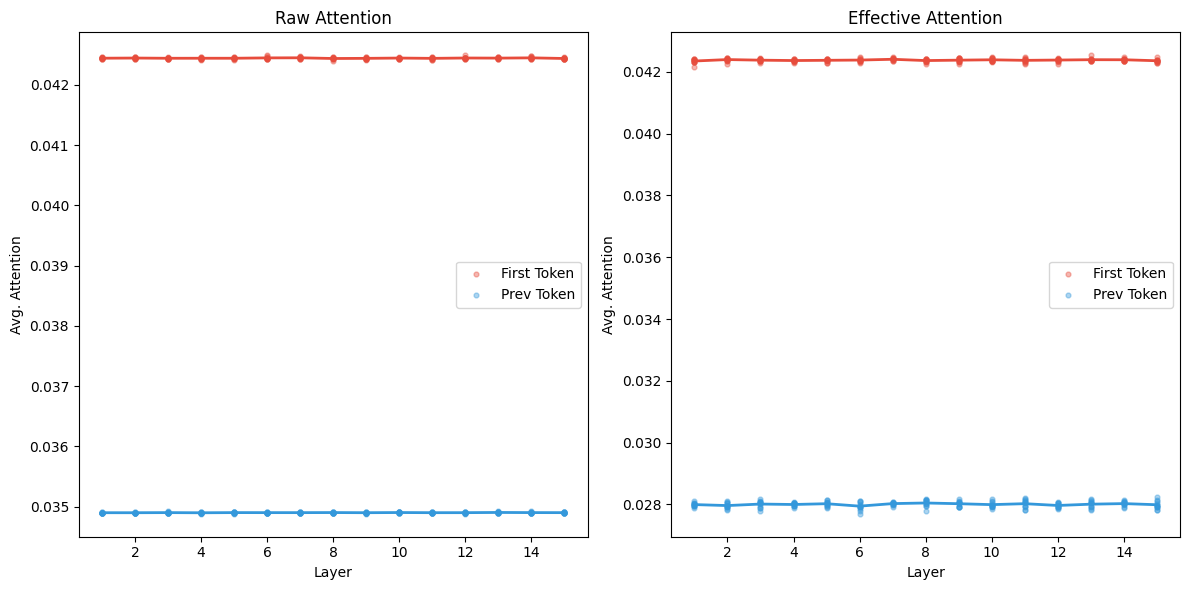

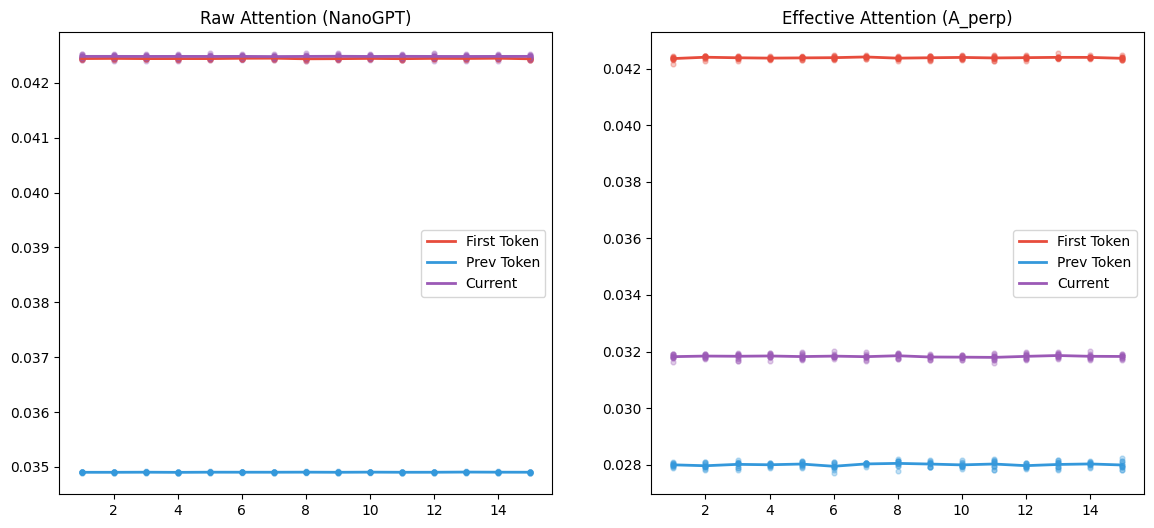

In [16]:

RED, BLUE, PURPLE = "#e74c3c", "#3498db", "#9b59b6"

def plot_comparison(key_list, title, data_dict):
    for key, color, label in key_list:
        xs, ys, avgs = get_data_points(data_dict[key])
        plt.scatter(xs, ys, s=12, label=label, color=color, alpha=0.4)
        plt.plot(1 + np.arange(len(avgs)), avgs, color=color, linewidth=2)
    plt.title(title)
    plt.legend(loc="best")
    plt.xlabel("Layer")
    plt.ylabel("Avg. Attention")

plt.figure(figsize=(12, 6))

# Subplot 1: Raw Attention
plt.subplot(1, 2, 1)
plot_comparison([("first", RED, "First Token"), ("prev", BLUE, "Prev Token")], 
                "Raw Attention", avg_attns_raw)

# Subplot 2: Effective Attention
plt.subplot(1, 2, 2)
plot_comparison([("first", RED, "First Token"), ("prev", BLUE, "Prev Token")], 
                "Effective Attention", avg_attns_eff)

plt.tight_layout()
plt.show()


RED, BLUE, PURPLE = "#e74c3c", "#3498db", "#9b59b6"

def get_data_points(stat_matrix):
    # stat_matrix is (layers, heads)
    xs, ys, avgs = [], [], []
    for l in range(stat_matrix.shape[0]):
        for h in range(stat_matrix.shape[1]):
            xs.append(l + 1)
            ys.append(stat_matrix[l, h])
        avgs.append(stat_matrix[l].mean())
    return xs, ys, avgs

plt.figure(figsize=(14, 6))

# Left: Raw Attention (Figure 1b style)
ax1 = plt.subplot(1, 2, 1)
for key, color, label in [("first", RED, "First Token"), ("prev", BLUE, "Prev Token"), ("self", PURPLE, "Current")]:
    xs, ys, avgs = get_data_points(avg_attns_raw[key])
    ax1.scatter(xs, ys, s=12, color=color, alpha=0.3)
    ax1.plot(range(1, n_layers+1), avgs, color=color, label=label, linewidth=2)
ax1.set_title("Raw Attention (NanoGPT)")
ax1.legend()

# Right: Effective Attention (Figure 1c style)
ax2 = plt.subplot(1, 2, 2)
for key, color, label in [("first", RED, "First Token"), ("prev", BLUE, "Prev Token"), ("self", PURPLE, "Current")]:
    xs, ys, avgs = get_data_points(avg_attns_eff[key])
    ax2.scatter(xs, ys, s=12, color=color, alpha=0.3)
    ax2.plot(range(1, n_layers+1), avgs, color=color, label=label, linewidth=2)
ax2.set_title("Effective Attention (A_perp)")
ax2.legend()

plt.show()

/var/folders/lk/p57c2c1x0kv0ptbl_lm3h0ww0000gn/T/ipykernel_4220/2674133239.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


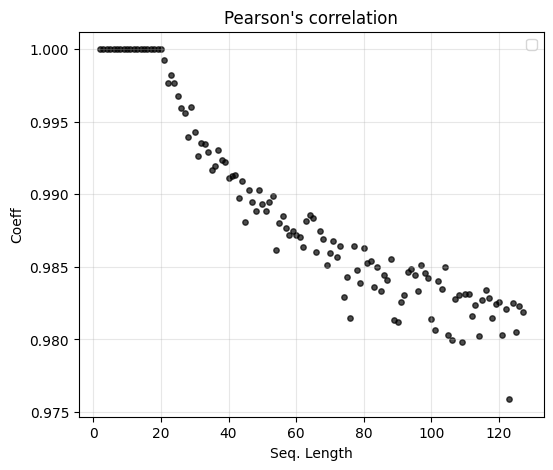

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def get_effective_attn(A, T):
    # A: (seq_len, seq_len), T: (seq_len, head_size)
    U, S, Vh = torch.linalg.svd(T, full_matrices=True)
    r = torch.sum(S > 1e-5).item()
    U_null = U[:, r:]
    A_proj_null = U_null @ U_null.mT @ A
    return A - A_proj_null

# Parameters from your NanoGPT config
head_size = model.config.n_embd // model.config.n_head
max_seq_len = 128 # The x-axis limit from Figure 1a
n_samples = 300    # Number of points to plot

seq_lengths = np.random.randint(2, 128, n_samples)
correlations = []

dv = model.config.n_embd // model.config.n_head 
max_len = model.config.block_size # Use the trained max length

correlations = []
seq_lengths = range(2, max_len) # Test lengths from 2 up to max

model.eval()
for ds in seq_lengths:
    # 1. Generate a dummy input sequence of exactly length 'ds'
    # This ensures T will be (ds, dv) and A will be (ds, ds)
    x = torch.randint(0, model.config.vocab_size, (1, ds)).to(device)
    
    # 2. Extract the REAL T and A from your model for this specific input
    # Note: Using your get_matricies function
    A_raw, T_real, _ = model.get_matricies(x, 0) # Layer 0, for example
    
    A_raw = torch.as_tensor(A_raw)
    T_real = torch.as_tensor(T_real)
    
    # 3. Compute effective attention
    A_eff = get_effective_attn(A_raw, T_real)
    
    # 4. Calculate correlation
    # This will now always work because A_raw and A_eff are both (ds, ds)
    r, _ = pearsonr(A_raw.cpu().flatten().numpy(), 
                    A_eff.cpu().flatten().numpy())
    correlations.append(r)

# Plotting Figure 1(a)
plt.figure(figsize=(6, 5))
plt.scatter(seq_lengths, correlations, color='black', s=15, alpha=0.7)
# plt.axvline(x=head_size, color='gray', linestyle='--', label=f'Head Dim (dv={head_size})')
plt.xlabel("Seq. Length")
plt.ylabel("Coeff")
plt.title("Pearson's correlation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Collected 200 sequences


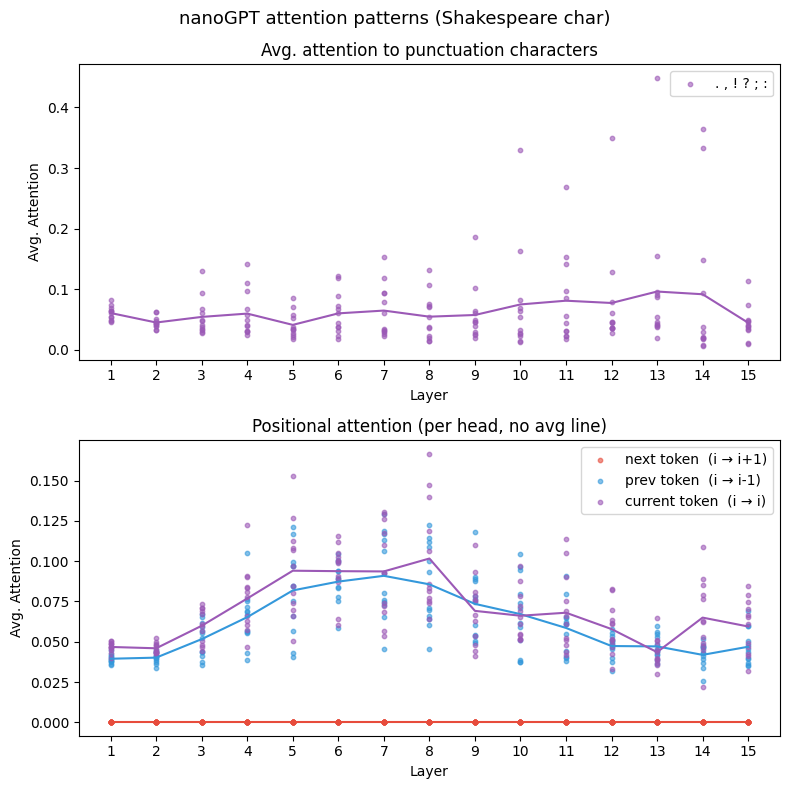

In [1]:
import os
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from model import GPTConfig, GPT

# ── Config — must match your training config ──────────────────────────────────
out_dir       = 'out-shakespeare-char'
dataset       = 'shakespeare_char'
data_dir      = os.path.join('data', dataset)
device        = 'cpu'
block_size    = 128
batch_size    = 16
n_layer       = 15
n_head        = 12

# ── Load checkpoint ───────────────────────────────────────────────────────────
ckpt_path  = os.path.join(out_dir, 'ckpt.pt')
checkpoint = torch.load(ckpt_path, map_location=device)

model_args = checkpoint['model_args']
gptconf    = GPTConfig(**model_args)
model      = GPT(gptconf)

state_dict = checkpoint['model']
# strip any DDP / compile prefix
unwanted_prefix = '_orig_mod.'
for k, v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)

model.load_state_dict(state_dict)
model.eval()

# ── Load tokenizer (char-level) ───────────────────────────────────────────────
meta_path = os.path.join(data_dir, 'meta.pkl')
with open(meta_path, 'rb') as f:
    meta = pickle.load(f)

itos = meta['itos']   # int → char

# ── Load validation data ───────────────────────────────────────────────────────
val_data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')

# ── Collect attention maps over N documents ───────────────────────────────────
N_DOCS = 200   # how many sequences to average over — increase for smoother curves

data = []   # list of {"tokens": [...], "attns": [n_layer, n_head, T, T]}

with torch.no_grad():
    for i in range(N_DOCS):
        start = i * block_size
        if start + block_size + 1 > len(val_data):
            break

        x = torch.tensor(
            val_data[start : start + block_size].astype(np.int64),
            dtype=torch.long,
            device=device
        ).unsqueeze(0)   # (1, T)

        # forward returns (logits, loss, attentions)
        # attentions is a list of n_layer tensors, each (B, n_head, T, T)
        _, _, attentions = model(x)

        tokens = [itos[int(idx)] for idx in x[0]]

        # stack → (n_layer, n_head, T, T), move to numpy
        attn_np = torch.stack(attentions, dim=0)   # (n_layer, B, n_head, T, T)
        attn_np = attn_np[:, 0, :, :, :]            # drop batch dim → (n_layer, n_head, T, T)
        attn_np = attn_np.cpu().numpy()

        data.append({"tokens": tokens, "attns": attn_np})

print(f"Collected {len(data)} sequences")

# ── Compute average attentions ────────────────────────────────────────────────
# For character-level Shakespeare there are no special tokens.
# We track: self, next (right), prev (left), and punctuation (. , ! ? ; :)

n_docs = len(data)
avg_attns = {
    k: np.zeros((n_layer, n_head))
    for k in ["self", "right", "left", "punct"]
}

PUNCT = set(".,'!?;:")

for doc in data:
    tokens = doc["tokens"]
    attns  = doc["attns"]   # (n_layer, n_head, T, T)
    n_tok  = attns.shape[-1]

    punct_mask = np.array([1.0 if t in PUNCT else 0.0 for t in tokens])

    selectors = {
        "self":  np.eye(n_tok),
        "right": np.eye(n_tok, n_tok, 1),    # query i attends to token i+1
        "left":  np.eye(n_tok, n_tok, -1),   # query i attends to token i-1
        "punct": np.tile(punct_mask[np.newaxis], [n_tok, 1]),
    }

    for key, sel in selectors.items():
        # attns: (n_layer, n_head, T, T)  sel: (T, T)
        # element-wise multiply and sum over both token dims
        avg_attns[key] += (
            (attns * sel[np.newaxis, np.newaxis]).sum(-1).sum(-1)
            / (n_docs * n_tok)
        )

# ── Plotting utilities ─────────────────────────────────────────────────────────
RED    = "#e74c3c"
BLUE   = "#3498db"
PURPLE = "#9b59b6"

def get_data_points(head_data):
    xs, ys, avgs = [], [], []
    for layer in range(n_layer):
        for head in range(n_head):
            ys.append(head_data[layer, head])
            xs.append(1 + layer)
        avgs.append(head_data[layer].mean())
    return xs, ys, avgs

def add_line(key, ax, color, label, plot_avgs=True):
    xs, ys, avgs = get_data_points(avg_attns[key])
    ax.scatter(xs, ys, s=10, label=label, color=color, alpha=0.6)
    if plot_avgs:
        ax.plot(1 + np.arange(n_layer), avgs, color=color)
    ax.legend(loc="best")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Avg. Attention")
    ax.set_xticks(range(1, n_layer + 1))

# ── Figure: analogous to BERT paper Fig 1 (b) and (c) ────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
fig.suptitle("nanoGPT attention patterns (Shakespeare char)", fontsize=13)

# --- Subplot 1: special / punctuation token attention (Fig 1b analogue) ------
ax = axes[0]
add_line("punct", ax, PURPLE, ". , ! ? ; :")
ax.set_title("Avg. attention to punctuation characters")

# --- Subplot 2: positional attention — next / prev / self (Fig 1c analogue) --
ax = axes[1]
for key, color, label in [
    ("right", RED,    "next token  (i → i+1)"),
    ("left",  BLUE,   "prev token  (i → i-1)"),
    ("self",  PURPLE, "current token  (i → i)"),
]:
    add_line(key, ax, color, label, plot_avgs=True)
ax.set_title("Positional attention (per head, no avg line)")

plt.tight_layout()
plt.savefig("attn_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

Processing Effective Attention: 100%|██████████| 200/200 [00:00<00:00, 13031.86it/s]


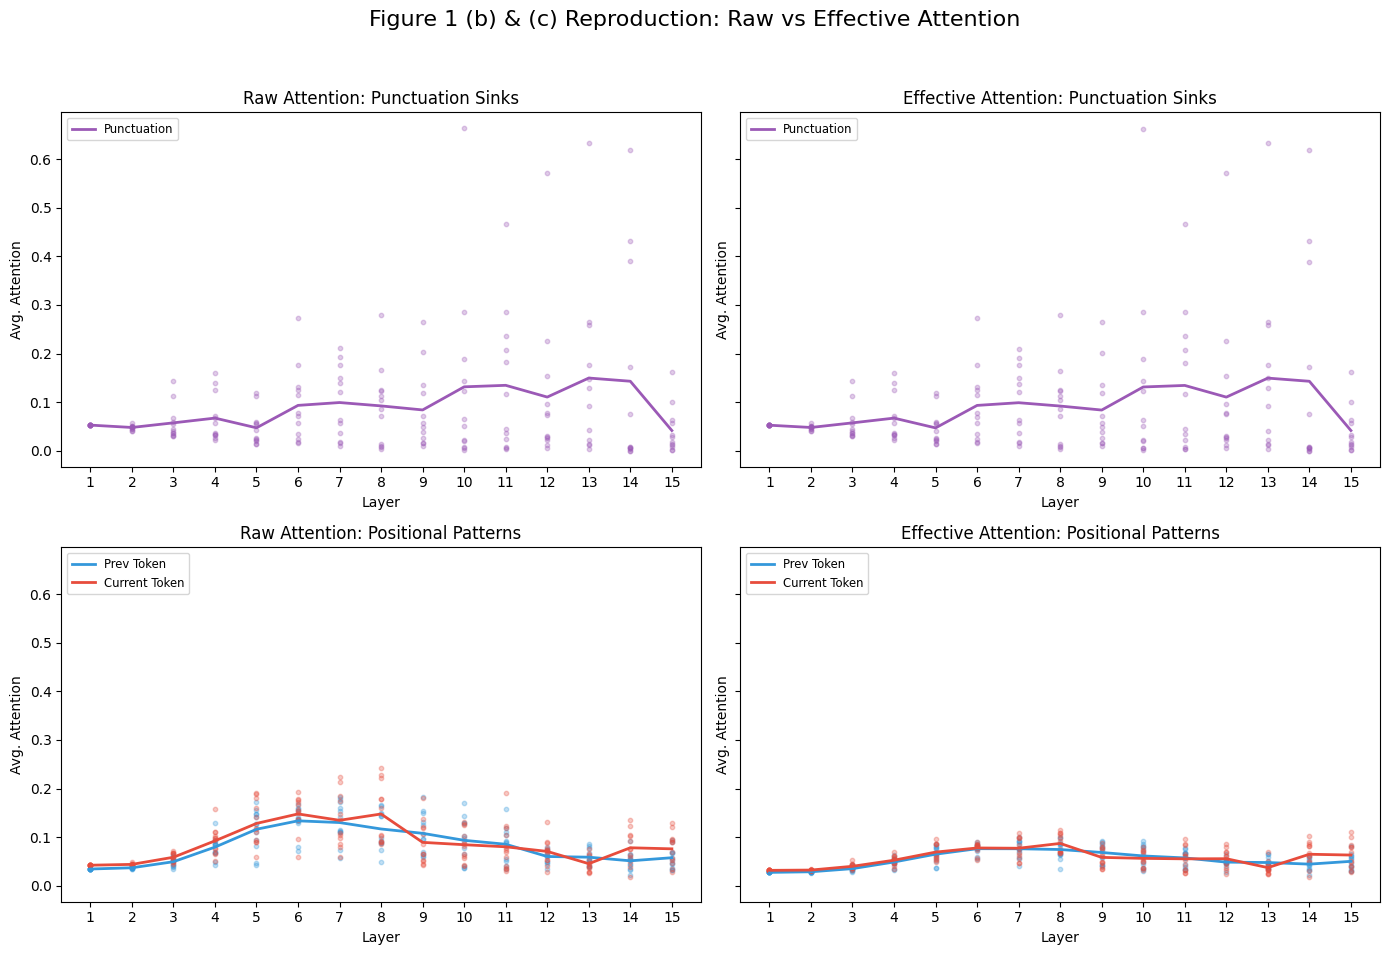

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# --- 1. THE MATH: EFFECTIVE ATTENTION ---
def get_effective_attn_np(A, T_mat):
    """ Removes components of A that fall into the left null space of T. """
    u, s, vh = np.linalg.svd(T_mat, full_matrices=True)
    r = np.sum(s > 1e-5) # Rank
    if r >= A.shape[0]: return A
    u_null = u[:, r:]
    return A - (u_null @ u_null.T @ A)

# --- 2. DATA COLLECTION ---
n_docs = len(data)
dv = gptconf.n_embd // gptconf.n_head # Head dimension

# Storage for Raw and Effective
avg_attns = {k: np.zeros((n_layer, n_head)) for k in ["self", "left", "punct"]}
avg_attns_eff = {k: np.zeros((n_layer, n_head)) for k in ["self", "left", "punct"]}

PUNCT = set(".,'!?;:")

for doc in tqdm(data, desc="Processing Effective Attention"):
    tokens = doc["tokens"]
    attns  = doc["attns"]   # (n_layer, n_head, T, T)
    n_tok  = attns.shape[-1]
    punct_mask = np.array([1.0 if t in PUNCT else 0.0 for t in tokens])

    # Storage for results
avg_attns = {k: np.zeros((n_layer, n_head)) for k in ["self", "left", "punct"]}
avg_attns_eff = {k: np.zeros((n_layer, n_head)) for k in ["self", "left", "punct"]}

with torch.no_grad():
    for i in tqdm(range(N_DOCS), desc="Collecting Real Matrices"):
        start = i * block_size
        if start + block_size + 1 > len(val_data): break
        
        # 1. Prepare input
        x = torch.tensor(val_data[start : start + block_size].astype(np.int64), 
                         dtype=torch.long, device=device).unsqueeze(0)
        
        tokens = [itos[int(idx)] for idx in x[0]]
        punct_mask = np.array([1.0 if t in PUNCT else 0.0 for t in tokens])
        n_tok = x.size(1)

        for l in range(n_layer):
            for h in range(n_head):
                # 2. EXTRACT REAL MATRICES FROM YOUR MODEL
                # We assume get_matricies(x, head_idx) returns: 
                # A_raw: (T, T) for that specific head
                # T_mat: (T, dv) the transformation matrix for that head
                A_raw, T_mat, _ = model.get_matricies(x,layer_idx = l,  head_idx=h) # head_idx=h
                
                # Convert to numpy for the SVD calculation
                A_raw_np = A_raw.cpu().numpy() if torch.is_tensor(A_raw) else A_raw
                T_mat_np = T_mat.cpu().numpy() if torch.is_tensor(T_mat) else T_mat
                
                # 3. CALCULATE EFFECTIVE ATTENTION
                A_eff_np = get_effective_attn_np(A_raw_np, T_mat_np)

                # 4. ACCUMULATE METRICS (using existing selectors logic)
                for key, offset in [("self", 0), ("left", -1)]:
                    sel = np.eye(n_tok, k=offset)
                    avg_attns[key][l, h] += (A_raw_np * sel).sum() / (N_DOCS * n_tok)
                    avg_attns_eff[key][l, h] += (A_eff_np * sel).sum() / (N_DOCS * n_tok)

                # Punctuation Mass
                sel_p = np.tile(punct_mask[np.newaxis], [n_tok, 1])
                avg_attns["punct"][l, h] += (A_raw_np * sel_p).sum() / (N_DOCS * n_tok)
                avg_attns_eff["punct"][l, h] += (A_eff_np * sel_p).sum() / (N_DOCS * n_tok)

# --- 3. PLOTTING (MATCHING YOUR FORMAT) ---
RED, BLUE, PURPLE = "#e74c3c", "#3498db", "#9b59b6"

def get_data_points(head_data):
    xs, ys, avgs = [], [], []
    for layer in range(n_layer):
        for head in range(n_head):
            ys.append(head_data[layer, head])
            xs.append(1 + layer)
        avgs.append(head_data[layer].mean())
    return xs, ys, avgs

def add_line(stats_dict, key, ax, color, label):
    xs, ys, avgs = get_data_points(stats_dict[key])
    ax.scatter(xs, ys, s=10, color=color, alpha=0.3)
    ax.plot(1 + np.arange(n_layer), avgs, color=color, linewidth=2, label=label)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Avg. Attention")
    ax.set_xticks(range(1, n_layer + 1))
    ax.legend(loc="upper left", fontsize='small')

# Create a 2x2 grid for comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

# RAW ATTENTION (Left Column)
axes[0,0].set_title("Raw Attention: Punctuation Sinks")
add_line(avg_attns, "punct", axes[0,0], PURPLE, "Punctuation")

axes[1,0].set_title("Raw Attention: Positional Patterns")
add_line(avg_attns, "left", axes[1,0], BLUE, "Prev Token")
add_line(avg_attns, "self", axes[1,0], RED, "Current Token")

# EFFECTIVE ATTENTION (Right Column)
axes[0,1].set_title("Effective Attention: Punctuation Sinks")
add_line(avg_attns_eff, "punct", axes[0,1], PURPLE, "Punctuation")

axes[1,1].set_title("Effective Attention: Positional Patterns")
add_line(avg_attns_eff, "left", axes[1,1], BLUE, "Prev Token")
add_line(avg_attns_eff, "self", axes[1,1], RED, "Current Token")

plt.suptitle("Figure 1 (b) & (c) Reproduction: Raw vs Effective Attention", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()